In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

In [33]:
df=pd.read_csv("seeds.csv")

In [34]:
df.head()

,Area,Perimeter,Compactness,Length of kernel,Width of kernel,Asymmetry coefficient,Length of kernel groove,"Class (1, 2, 3)"
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [35]:
df.tail()

,Area,Perimeter,Compactness,Length of kernel,Width of kernel,Asymmetry coefficient,Length of kernel groove,"Class (1, 2, 3)"
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870,3
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003,3
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056,3
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,3
209,12.30,13.34,0.8684,5.243,2.974,5.637,5.063,3


In [36]:
df.shape

(210, 8)

In [37]:
df.columns

Index(['Area', 'Perimeter', 'Compactness', 'Length of kernel',
       'Width of kernel', 'Asymmetry coefficient', 'Length of kernel groove',
       'Class (1, 2, 3)'],
      dtype='object')

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Area                     210 non-null    float64
 1   Perimeter                210 non-null    float64
 2   Compactness              210 non-null    float64
 3   Length of kernel         210 non-null    float64
 4   Width of kernel          210 non-null    float64
 5   Asymmetry coefficient    210 non-null    float64
 6   Length of kernel groove  210 non-null    float64
 7   Class (1, 2, 3)          210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB


In [39]:
df.dtypes

,0
Area,float64
Perimeter,float64
Compactness,float64
Length of kernel,float64
Width of kernel,float64
Asymmetry coefficient,float64
Length of kernel groove,float64
"Class (1, 2, 3)",int64


In [40]:
df.describe()

,Area,Perimeter,Compactness,Length of kernel,Width of kernel,Asymmetry coefficient,Length of kernel groove,"Class (1, 2, 3)"
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071,2.000000
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480,0.818448
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000,1.000000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000,1.000000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000,2.000000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000,3.000000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000,3.000000


In [41]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Area,210.0,14.847524,2.909699,10.5900,12.27000,14.35500,17.305000,21.1800
Perimeter,210.0,14.559286,1.305959,12.4100,13.45000,14.32000,15.715000,17.2500
Compactness,210.0,0.870999,0.023629,0.8081,0.85690,0.87345,0.887775,0.9183
Length of kernel,210.0,5.628533,0.443063,4.8990,5.26225,5.52350,5.979750,6.6750
Width of kernel,210.0,3.258605,0.377714,2.6300,2.94400,3.23700,3.561750,4.0330
Asymmetry coefficient,210.0,3.700201,1.503557,0.7651,2.56150,3.59900,4.768750,8.4560
Length of kernel groove,210.0,5.408071,0.491480,4.5190,5.04500,5.22300,5.877000,6.5500
"Class (1, 2, 3)",210.0,2.000000,0.818448,1.0000,1.00000,2.00000,3.000000,3.0000


In [42]:
df.isnull().sum()

,0
Area,0
Perimeter,0
Compactness,0
Length of kernel,0
Width of kernel,0
Asymmetry coefficient,0
Length of kernel groove,0
"Class (1, 2, 3)",0


In [43]:
df.duplicated().sum()

np.int64(0)

In [54]:
X=df.drop("Class (1, 2, 3)",axis=1)
y_original=df["Class (1, 2, 3)"]
print("Input shape:",X.shape)
print("Output shape:",y_original.shape)

Input shape: (210, 7)
Output shape: (210,)


In [59]:
y=y_original-1
print("Original classes:")
print(sorted(y_original.unique()))
print("ANN encoded classes:")
print(sorted(y.unique()))

Original classes:
[np.int64(1), np.int64(2), np.int64(3)]
ANN encoded classes:
[np.int64(0), np.int64(1), np.int64(2)]


In [60]:
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42,stratify=y)
print("Training samples:",X_train.shape[0])
print("Testing samples:",X_test.shape[0])

Training samples: 168
Testing samples: 42


In [61]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [62]:
scaler.fit_transform(X_test)

array([[-0.13481356, -0.30885661,  1.63834475, -0.72108928,  0.28326462,
        -0.76430253, -1.20943602],
       [-0.86696115, -0.79265998, -1.079508  , -0.44412568, -1.01611436,
        -0.08296069, -0.1493714 ],
       [ 0.3031065 ,  0.49244271, -0.70339658,  0.66153059,  0.00779627,
        -0.80711315,  0.9685525 ],
       [-1.32882996, -1.4578896 , -0.42131302, -1.40250766, -1.05769449,
         0.74059948, -0.71763216],
       [ 1.23710786,  1.05184035,  1.89804073,  0.79121989,  1.36954545,
        -0.66416923,  1.14006393],
       [-0.46667485, -0.42224803, -0.31833013, -0.17155833, -0.40280748,
         2.38191499,  0.06140168],
       [ 2.15058173,  2.0799225 ,  0.78313902,  2.07492419,  1.98285233,
         0.67094153,  1.87157051],
       [ 0.37495276,  0.31101645,  1.0697001 ,  0.12079214,  0.53534414,
         1.33559449, -0.56678476],
       [ 1.65107916,  1.67171341,  0.42941519,  1.6418938 ,  1.48908831,
        -0.57346877,  1.60087175],
       [ 1.28842662,  1.2257

In [63]:
model=Sequential([
Input(shape=(7,)),
Dense(16,activation="relu"),
Dense(8,activation="relu"),
Dense(3,activation="softmax")
])

In [64]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 291 (1.14 KB)

 Trainable params: 291 (1.14 KB)

 Non-trainable params: 0 (0.00 B)

In [65]:
model.compile(optimizer=Adam(learning_rate=0.001),loss="sparse_categorical_crossentropy",
              metrics=["accuracy"]
)

In [66]:
loss="sparse_categorical_crossentropy"

In [72]:
early_stopping=EarlyStopping(monitor="val_loss",patience=10,restore_best_weights=True)

In [75]:
history=model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=1)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9552 - loss: 0.1208 - val_accuracy: 0.9412 - val_loss: 0.1623
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9552 - loss: 0.1182 - val_accuracy: 0.9412 - val_loss: 0.1630
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9552 - loss: 0.1159 - val_accuracy: 0.9412 - val_loss: 0.1611
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9552 - loss: 0.1138 - val_accuracy: 0.9412 - val_loss: 0.1590
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9552 - loss: 0.1120 - val_accuracy: 0.9412 - val_loss: 0.1553
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9552 - loss: 0.1097 - val_accuracy: 0.9412 - val_loss: 0.1537
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9552 - loss: 0.1088 - val_accuracy: 0.9412 - val_loss: 0.1510
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9627 - loss: 0.1059 - val_accuracy: 0.9412 - val_loss:

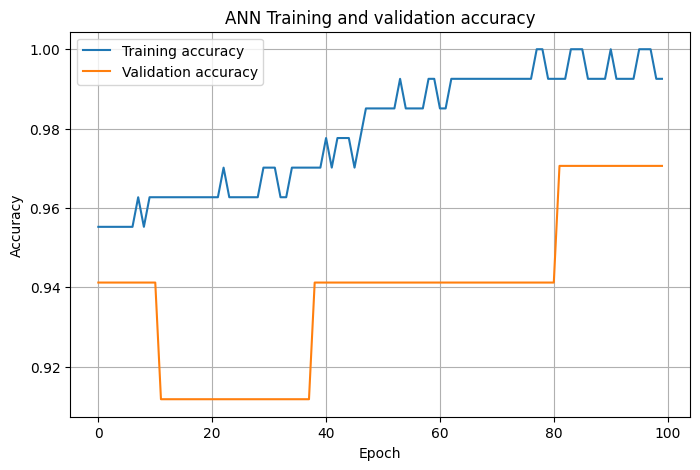

In [76]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"],label="Training accuracy")
plt.plot(history.history["val_accuracy"],label="Validation accuracy")
plt.title("ANN Training and validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

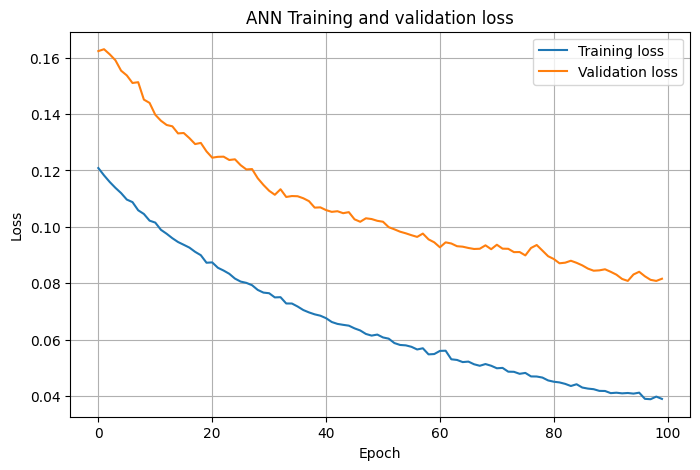

In [77]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"],label="Training loss")
plt.plot(history.history["val_loss"],label="Validation loss")
plt.title("ANN Training and validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [78]:
test_loss,test_accuracy=model.evaluate(X_test_scaled,y_test,verbose=1)
print("Test loss:",test_loss)
print("Test accuracy:",test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8571 - loss: 0.4610
Test loss: 0.4610470235347748
Test accuracy: 0.8571428656578064


In [79]:
y_prob=model.predict(X_test_scaled,verbose=1)
print(y_prob[:10])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
[[9.9882585e-01 6.0567403e-05 1.1135159e-03]
 [3.9425725e-03 4.7903264e-05 9.9600947e-01]
 [7.9225767e-01 1.7711563e-01 3.0626610e-02]
 [4.6869602e-05 1.4522218e-06 9.9995166e-01]
 [3.4175752e-04 9.9964380e-01 1.4368007e-05]
 [4.4382669e-02 1.5761876e-02 9.3985540e-01]
 [3.5497496e-07 9.9999958e-01 1.3658102e-08]
 [6.7770362e-01 3.2124251e-01 1.0538052e-03]
 [2.2479768e-05 9.9997646e-01 9.2191561e-07]
 [2.8061830e-03 9.9715608e-01 3.7699716e-05]]


In [80]:
y_pred=np.argmax(y_prob,axis=1)
print("Predicted encoded classes:")
print(y_pred[:10])

Predicted encoded classes:
[0 2 0 2 1 2 1 0 1 1]


In [81]:
y_pred_original=y_pred+1
y_test_original=y_test+1
print("Predicted classes:")
print(y_pred_original[:10])

Predicted classes:
[1 3 1 3 2 3 2 1 2 2]


In [83]:
comparison=pd.DataFrame({"Actual":y_test_original.values,"Predicted":y_pred_original})
comparison.head(15)

,Actual,Predicted
0,1,1
1,3,3
2,2,1
3,3,3
4,2,2
5,3,3
6,2,2
7,1,1
8,2,2
9,2,2


In [84]:
accuracy=accuracy_score(y_test_original,y_pred_original)
print("Accuracy:",accuracy)

Accuracy: 0.8571428571428571


In [85]:
precision=precision_score(y_test_original,y_pred_original,average="weighted")
print("Precision:",precision)

Precision: 0.8633986928104576


In [86]:
recall=recall_score(y_test_original,y_pred_original,average="weighted")
print("Recall:",recall)

Recall: 0.8571428571428571


In [87]:
f1=f1_score(y_test_original,y_pred_original,average="weighted")
print("F1 score:",f1)

F1 score: 0.849925843529848


In [89]:
metrics=pd.DataFrame({
    "Metric":["accuracy","precision","recall","f1"],
    "Value":[accuracy,precision,recall,f1]
})
metrics.head()


,Metric,Value
0,accuracy,0.857143
1,precision,0.863399
2,recall,0.857143
3,f1,0.849926


In [90]:
print(classification_report(y_test_original,y_pred_original))

              precision    recall  f1-score   support

           1       0.90      0.64      0.75        14
           2       0.87      0.93      0.90        14
           3       0.82      1.00      0.90        14

    accuracy                           0.86        42
   macro avg       0.86      0.86      0.85        42
weighted avg       0.86      0.86      0.85        42



In [91]:
cm=confusion_matrix(y_test_original,y_pred_original)
print(cm)

[[ 9  2  3]
 [ 1 13  0]
 [ 0  0 14]]


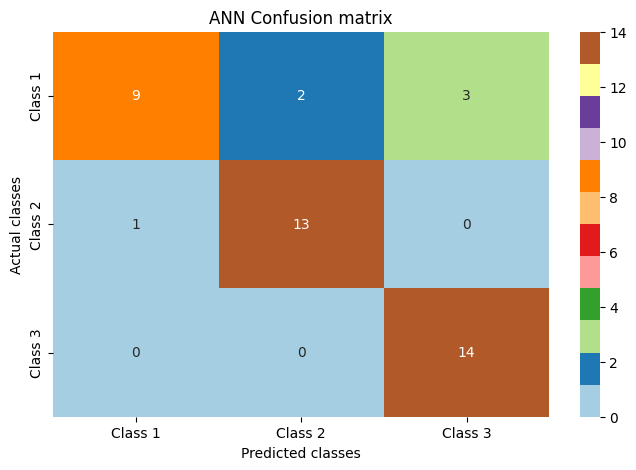

In [94]:
plt.figure(figsize=(8,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Paired",xticklabels=["Class 1","Class 2","Class 3"],
            yticklabels=["Class 1","Class 2","Class 3"])
plt.title("ANN Confusion matrix")
plt.xlabel("Predicted classes")
plt.ylabel("Actual classes")
plt.show()

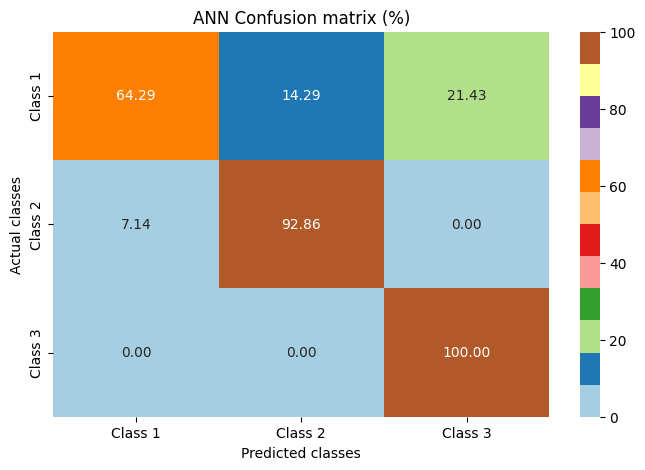

In [95]:
cm_percentage=cm.astype(float)/cm.sum(axis=1)[:,np.newaxis]*100
plt.figure(figsize=(8,5))
sns.heatmap(cm_percentage,annot=True,fmt=".2f",cmap="Paired",
            xticklabels=["Class 1","Class 2","Class 3"],
            yticklabels=["Class 1","Class 2","Class 3"]
)
plt.title("ANN Confusion matrix (%)")
plt.xlabel("Predicted classes")
plt.ylabel("Actual classes")
plt.show()

In [105]:
def predict_new_seeds(
    area,
    perimeter,
    compactness,
    length,width,
    asymmetry,
    groove_length
):
    new_sample=pd.DataFrame([[
        area,
        perimeter,
        compactness,
        length,
        width,
        asymmetry,
        groove_length
        ]],columns=X.columns)


In [106]:
area=float(input("Enter area:"))
perimeter=float(input("Enter perimeter:"))
compactness=float(input("Enter compactness:"))
length=float(input("Enter length of kernel:"))
width=float(input("Enter width of kernel:"))
asymmetry=float(input("Enter asymmetry coefficient:"))
groove_length=float(input("Enter length of groove:"))

predict_new_seeds(area,perimeter,compactness,length,width,asymmetry,groove_length)

Enter area:12
Enter perimeter:3
Enter compactness:45
Enter length of kernel:5
Enter width of kernel:2
Enter asymmetry coefficient:56
Enter length of groove:1
